# 📊 Multivariate Analysis

> **Folder:** `02_Exploratory_Data_Analysis / Multivariate_Analysis`  
> **Notebook:** `multivariate_analysis.ipynb`  
> **Author:** Hamna Munir

---

## 🎯 Objectives

By the end of this notebook, you will:

- Visualize **3+ variables simultaneously** using pair plots, hue scatter, 3D plots
- Detect **multicollinearity** using correlation matrix and VIF analysis
- Apply **PCA** to reduce dimensions and visualize high-dimensional structure in 2D
- Apply **t-SNE** to reveal non-linear cluster structure
- Compare **group profiles** using radar charts and parallel coordinates
- Build a complete **multivariate EDA summary report**

---

## 📚 Techniques Covered

| # | Technique | Purpose |
|---|-----------|--------|
| 1 | Pair Plot (Scatter Matrix) | All feature pairs at once |
| 2 | Hue-Colored Scatter Plot | 2 Numerical + 1 Categorical |
| 3 | Bubble Chart | 4 Variables simultaneously |
| 4 | 3D Scatter Plot | True 3D structure |
| 5 | Parallel Coordinates | High-dimensional feature profiles |
| 6 | Radar / Spider Chart | Group feature profile comparison |
| 7 | Correlation Matrix Heatmap | Detect pairwise multicollinearity |
| 8 | VIF Analysis | Regression multicollinearity |
| 9 | PCA — 2D Projection | Linear dimensionality reduction |
| 10 | PCA — Scree Plot | Choosing number of components |
| 11 | PCA — Biplot | Feature loading directions |
| 12 | t-SNE — 2D Projection | Non-linear cluster structure |
| 13 | Automated EDA Report | Full multivariate summary |

---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas.plotting import parallel_coordinates
from scipy.stats import pearsonr
from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'warning'  : '#F18F01',
    'purple'   : '#7B2D8B',
    'palette'  : ['#2E86AB','#E84855','#3BB273','#F18F01','#7B2D8B','#F4D35E'],
}

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 📊 1. Load & Inspect Dataset

In [2]:
np.random.seed(42)
n = 600

edu_levels = ["High School", "Bachelor's", "Master's", "PhD"]
edu_probs  = [0.25, 0.40, 0.25, 0.10]
education  = np.random.choice(edu_levels, n, p=edu_probs)

edu_salary = {"High School": 35_000, "Bachelor's": 60_000,
              "Master's": 90_000,    "PhD": 120_000}
base_salary = np.array([edu_salary[e] for e in education])

age        = np.random.randint(22, 65, n)
experience = np.clip(age - 22 + np.random.randint(-3, 8, n), 0, 40)
salary     = (base_salary + experience * 1500
              + np.random.normal(0, 10_000, n)).clip(20_000, 200_000)
score      = (50 + salary / 5000
              + np.random.normal(0, 8, n)).clip(0, 100)
savings    = (salary * 0.15 + np.random.normal(0, 3000, n)).clip(0)
debt       = (salary * 0.25 - experience * 500
              + np.random.normal(0, 5000, n)).clip(0)
income     = np.random.exponential(50_000, n)

df = pd.DataFrame({
    'Age'         : age,
    'Experience'  : experience,
    'Salary'      : salary.astype(int),
    'Score'       : score.round(1),
    'Savings'     : savings.astype(int),
    'Debt'        : debt.astype(int),
    'Income'      : income.astype(int),
    'Num_Products': np.random.randint(1, 15, n),
    'Education'   : education,
    'City'        : np.random.choice(
                        ['London','Paris','Berlin','Tokyo','Sydney'], n,
                        p=[0.35,0.25,0.20,0.12,0.08]),
    'Gender'      : np.random.choice(['Male','Female'], n, p=[0.50,0.50]),
    'Churn'       : np.random.choice([0, 1], n, p=[0.78, 0.22]),
})

num_cols  = ['Age','Experience','Salary','Score','Savings','Debt','Income','Num_Products']
cat_cols  = ['Education','City','Gender']
edu_order = ["High School", "Bachelor's", "Master's", "PhD"]
target    = 'Churn'

print(f'Shape   : {df.shape}')
print(f'Numeric : {num_cols}')
print(f'Categ.  : {cat_cols}')
df.head()

Shape   : (600, 12)
Numeric : ['Age', 'Experience', 'Salary', 'Score', 'Savings', 'Debt', 'Income', 'Num_Products']
Categ.  : ['Education', 'City', 'Gender']


,Age,Experience,Salary,Score,Savings,Debt,Income,Num_Products,Education,City,Gender,Churn
0,26,2,51115,52.3000,3654,21260,99564,4,Bachelor's,London,Female,0
1,39,14,144120,75.1000,22336,30129,18466,13,PhD,Paris,Male,0
2,49,33,152191,91.9000,18788,28510,17374,9,Master's,Paris,Female,0
3,63,39,125477,72.9000,19945,1623,15462,5,Bachelor's,Paris,Male,1
4,43,24,102419,81.7000,12971,17675,20231,14,High School,Paris,Male,1


In [3]:
# ── Extended descriptive statistics ───────────────────────────────────────
desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew().round(3)
desc['IQR']      = (df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)).round(1)
desc

,count,mean,std,min,25%,50%,75%,max,skewness,IQR
Age,600.0000,43.3533,12.3614,22.0000,32.0000,44.0000,54.0000,64.0000,-0.0640,22.0000
Experience,600.0000,22.9450,12.2745,0.0000,13.0000,24.0000,34.0000,40.0000,-0.1750,21.0000
Salary,600.0000,101699.9750,33219.1599,24755.0000,78228.0000,100624.0000,123630.2500,193896.0000,0.1630,45402.2000
Score,600.0000,70.7135,10.6284,43.7000,63.4000,70.7500,77.8000,100.0000,0.0400,14.4000
Savings,600.0000,15515.7767,5686.0676,0.0000,11315.5000,15345.5000,19652.0000,33371.0000,0.0520,8336.5000
Debt,600.0000,13803.0317,8690.1611,0.0000,7323.7500,13075.0000,19776.5000,38679.0000,0.3860,12452.8000
Income,600.0000,47835.8533,44154.9350,46.0000,14756.2500,35179.5000,68673.7500,269897.0000,1.6240,53917.5000
Num_Products,600.0000,7.3850,4.0092,1.0000,4.0000,7.0000,11.0000,14.0000,0.0520,7.0000


---
## 1️⃣ Pair Plot (Scatter Matrix)

> Plots **every numerical variable against every other** in a grid.  
> The diagonal shows each variable's univariate distribution (KDE).  
> Color (`hue`) encodes the target class to reveal class separability.
>
> ✅ The single most comprehensive multivariate visualization in EDA.

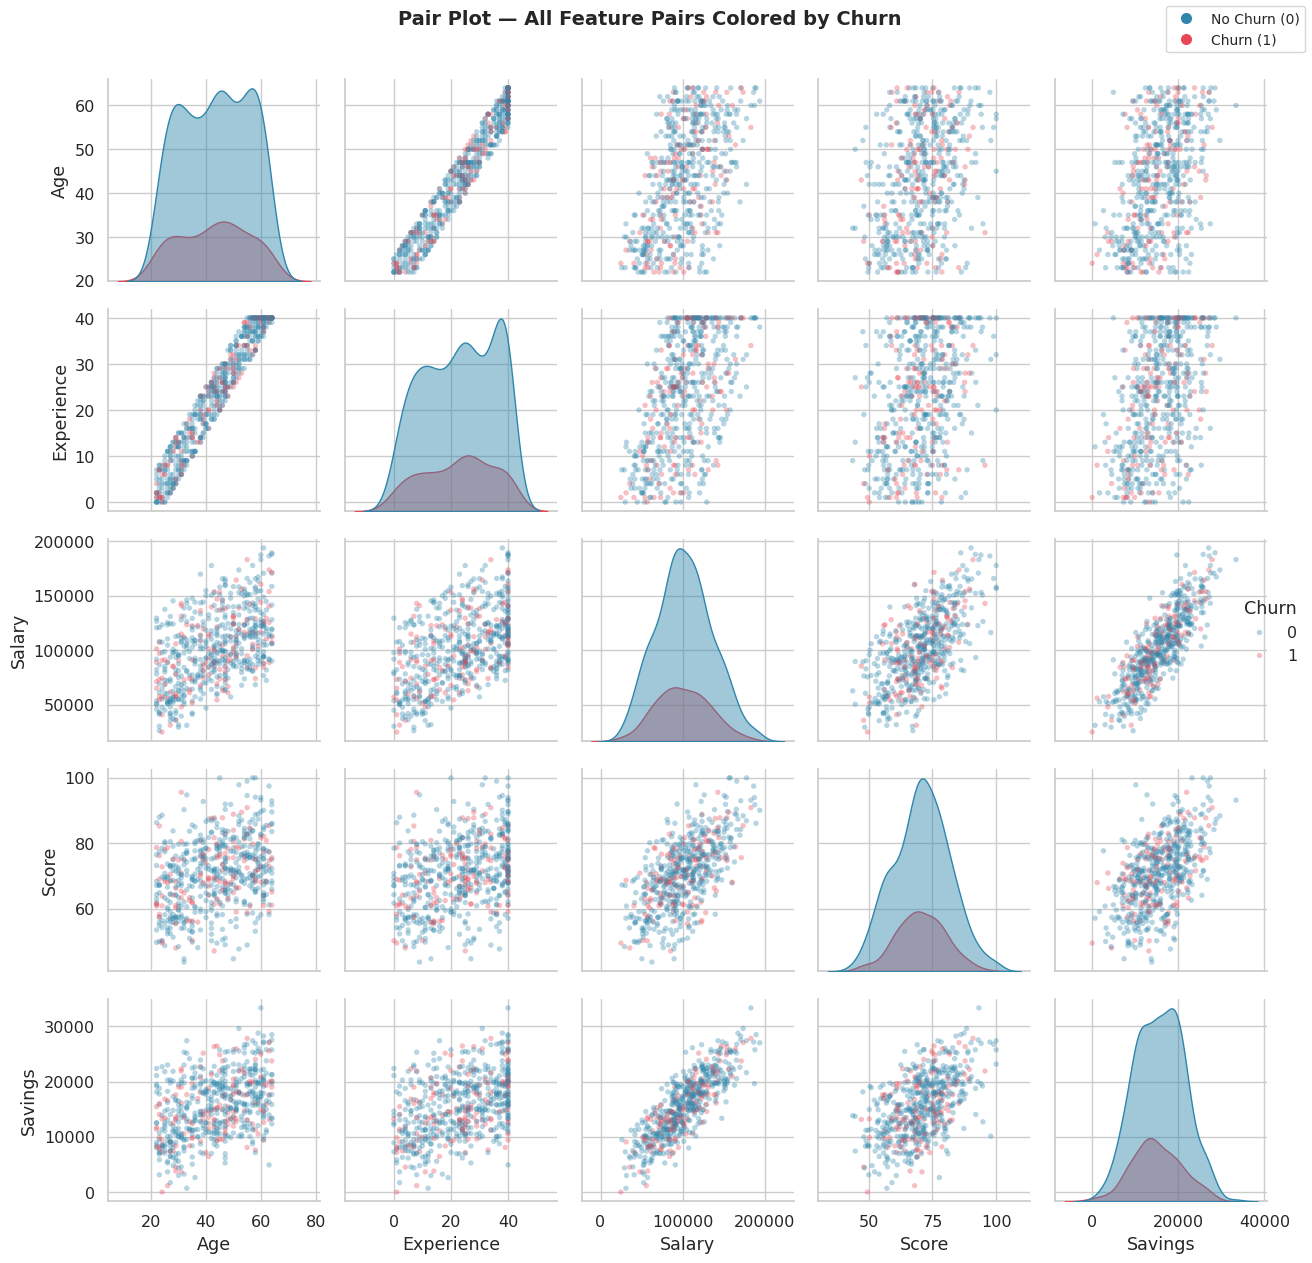

In [4]:
# ── Pair plot — colored by Churn ──────────────────────────────────────────
pair_cols = ['Age', 'Experience', 'Salary', 'Score', 'Savings', 'Churn']

g = sns.pairplot(
    df[pair_cols],
    hue='Churn',
    palette={0: COLORS['primary'], 1: COLORS['secondary']},
    diag_kind='kde',
    plot_kws=dict(alpha=0.35, s=15, edgecolor='none'),
    diag_kws=dict(fill=True, alpha=0.45),
    corner=False,
)
g.figure.suptitle('Pair Plot — All Feature Pairs Colored by Churn',
                   fontsize=14, fontweight='bold', y=1.01)

handles = [
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=COLORS['primary'],   markersize=9, label='No Churn (0)'),
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=COLORS['secondary'], markersize=9, label='Churn (1)'),
]
g.figure.legend(handles=handles, loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

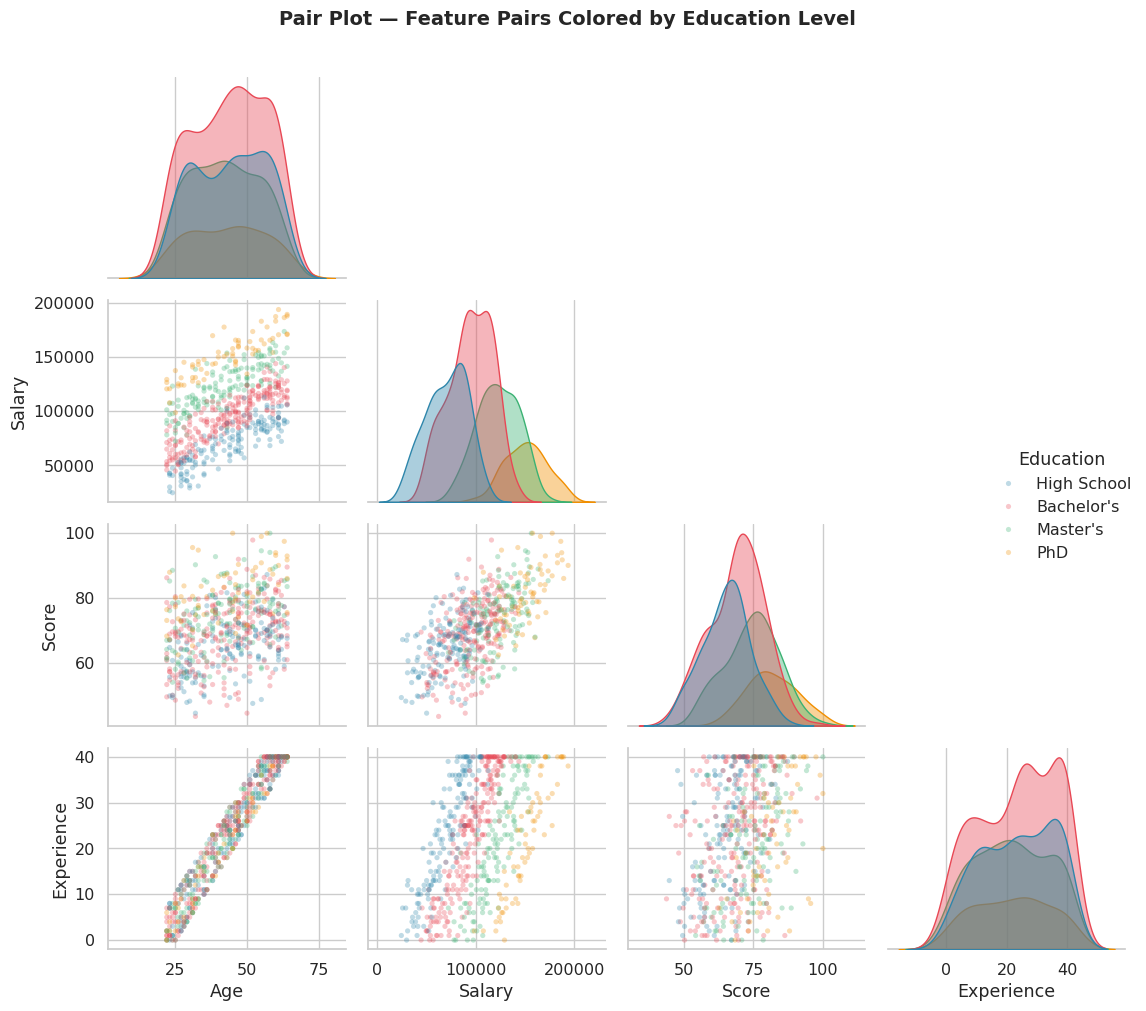

In [5]:
# ── Pair plot — colored by Education (lower triangle only) ────────────────
edu_palette = dict(zip(edu_order, COLORS['palette'][:4]))

g2 = sns.pairplot(
    df[['Age','Salary','Score','Experience','Education']],
    hue='Education',
    hue_order=edu_order,
    palette=edu_palette,
    diag_kind='kde',
    plot_kws=dict(alpha=0.30, s=14, edgecolor='none'),
    diag_kws=dict(fill=True, alpha=0.40),
    corner=True,
)
g2.figure.suptitle('Pair Plot — Feature Pairs Colored by Education Level',
                    fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 2️⃣ Hue-Colored Scatter Plot

> A standard scatter with a **third variable encoded as color**.  
> Instantly reveals whether a categorical grouping separates in 2D feature space.
>
> ✅ Most readable way to explore 2 numerical + 1 categorical variable together.

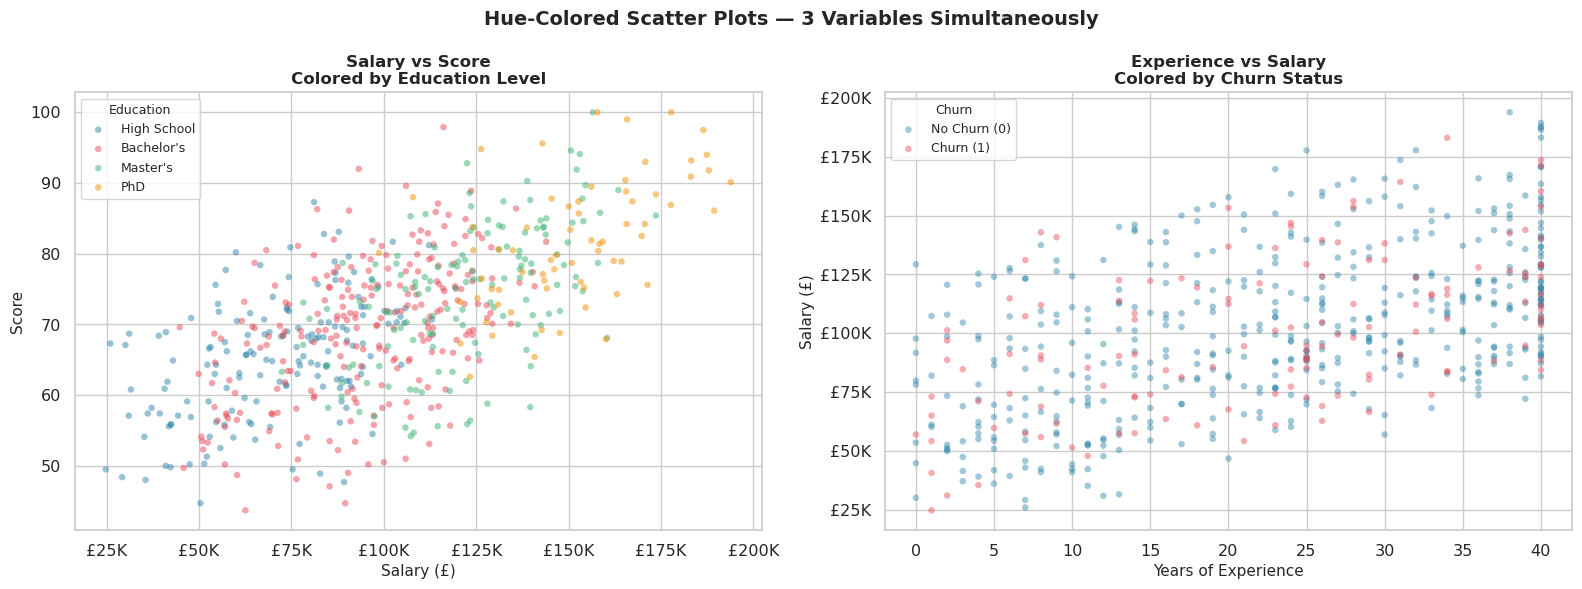

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Salary vs Score, hue = Education ──────────────────────────────
for edu, color in zip(edu_order, COLORS['palette'][:4]):
    mask = df['Education'] == edu
    axes[0].scatter(
        df.loc[mask, 'Salary'], df.loc[mask, 'Score'],
        c=color, label=edu, alpha=0.50, s=22, edgecolors='none'
    )
axes[0].set_xlabel('Salary (£)', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Salary vs Score\nColored by Education Level',
                   fontsize=12, fontweight='bold')
axes[0].legend(title='Education', fontsize=9, title_fontsize=9)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

# ── Plot 2: Experience vs Salary, hue = Churn ─────────────────────────────
for churn_val, color, label in [
    (0, COLORS['primary'],   'No Churn (0)'),
    (1, COLORS['secondary'], 'Churn (1)')
]:
    mask = df['Churn'] == churn_val
    axes[1].scatter(
        df.loc[mask, 'Experience'], df.loc[mask, 'Salary'],
        c=color, label=label, alpha=0.45, s=22, edgecolors='none'
    )
axes[1].set_xlabel('Years of Experience', fontsize=11)
axes[1].set_ylabel('Salary (£)', fontsize=11)
axes[1].set_title('Experience vs Salary\nColored by Churn Status',
                   fontsize=12, fontweight='bold')
axes[1].legend(title='Churn', fontsize=9, title_fontsize=9)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.suptitle('Hue-Colored Scatter Plots — 3 Variables Simultaneously',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3️⃣ Bubble Chart — 4 Variables at Once

> Extends scatter by encoding a **third numerical variable as point size**  
> and a **fourth categorical variable as color**.
>
> ✅ Compact — 4 dimensions in a single 2D plot.

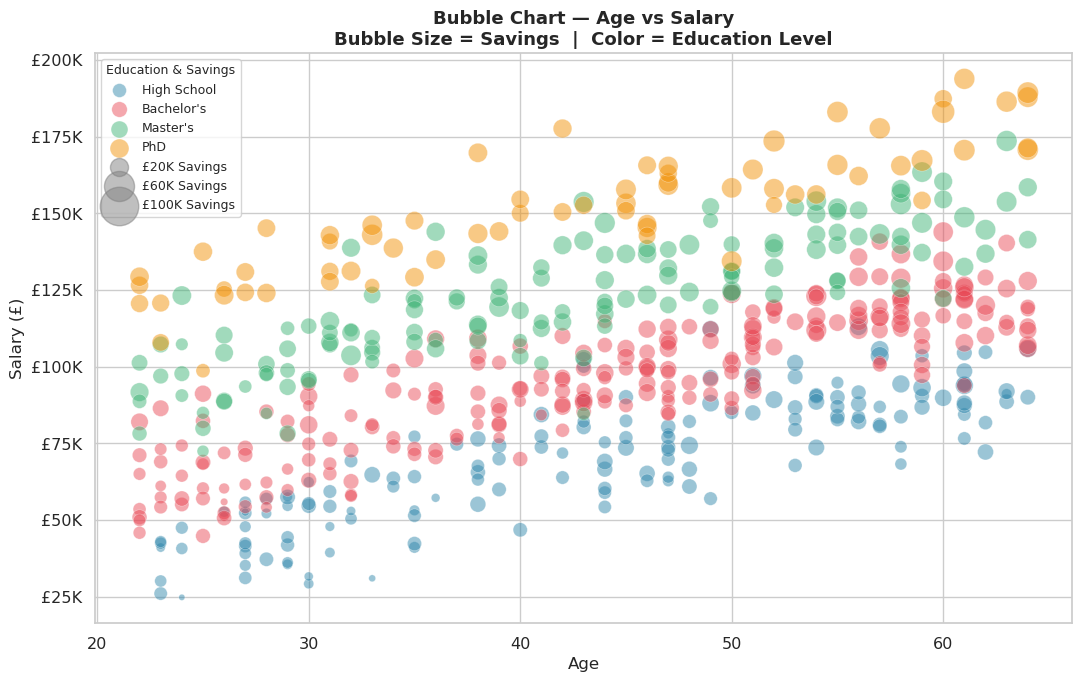

In [7]:
fig, ax = plt.subplots(figsize=(11, 7))

# Normalize Savings to bubble size range [20, 270]
s_min, s_max = df['Savings'].min(), df['Savings'].max()
bubble_size  = ((df['Savings'] - s_min) / (s_max - s_min)) * 250 + 20

for edu, color in zip(edu_order, COLORS['palette'][:4]):
    mask = df['Education'] == edu
    ax.scatter(
        df.loc[mask, 'Age'],
        df.loc[mask, 'Salary'],
        s=bubble_size[mask],
        c=color, alpha=0.48,
        edgecolors='white', linewidths=0.4,
        label=edu
    )

# Legend for bubble sizes
for sav_val, lbl in [(20_000,'£20K Savings'), (60_000,'£60K Savings'), (100_000,'£100K Savings')]:
    norm_s = ((sav_val - s_min) / (s_max - s_min)) * 250 + 20
    ax.scatter([], [], s=norm_s, c='gray', alpha=0.5, label=lbl)

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Salary (£)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title(
    'Bubble Chart — Age vs Salary\n'
    'Bubble Size = Savings  |  Color = Education Level',
    fontsize=13, fontweight='bold'
)
ax.legend(title='Education & Savings', fontsize=9, title_fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

---
## 4️⃣ 3D Scatter Plot

> Places three numerical features on X, Y, Z axes — color encodes a fourth variable.  
> Reveals 3D cluster structure that any 2D projection alone would miss.
>
> ✅ Best explored interactively — rotate the plot to find the most revealing angle.

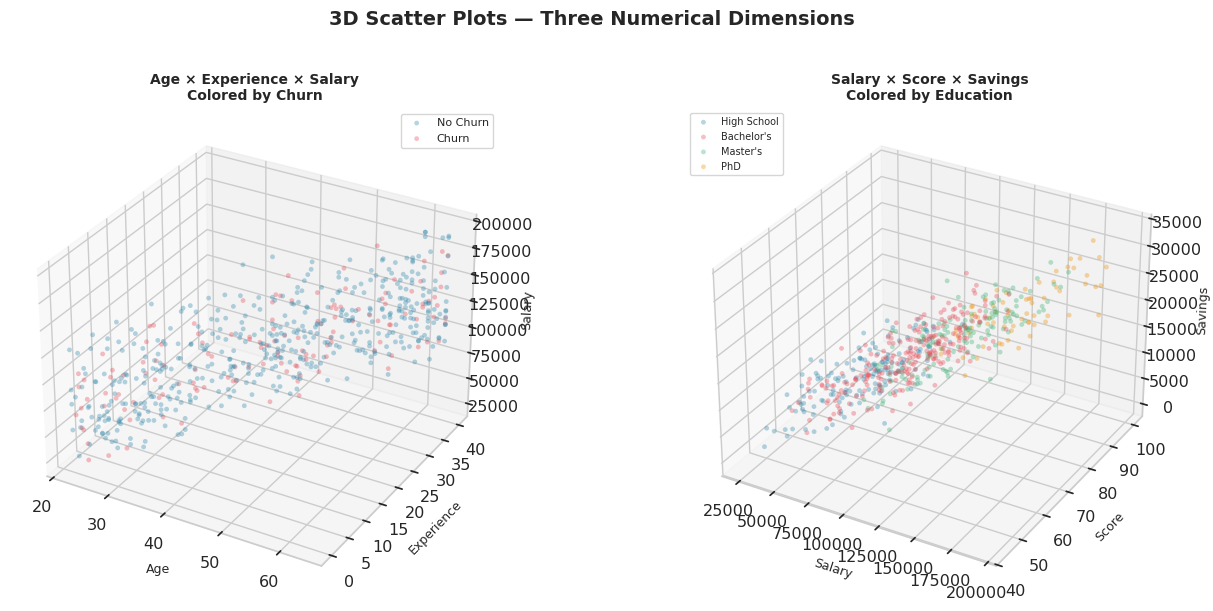

In [8]:
fig = plt.figure(figsize=(14, 6))

# ── Left: Age × Experience × Salary, colored by Churn ────────────────────
ax1 = fig.add_subplot(121, projection='3d')
for churn_val, color, label in [
    (0, COLORS['primary'],   'No Churn'),
    (1, COLORS['secondary'], 'Churn')
]:
    mask = df['Churn'] == churn_val
    ax1.scatter(
        df.loc[mask, 'Age'],
        df.loc[mask, 'Experience'],
        df.loc[mask, 'Salary'],
        c=color, alpha=0.35, s=12, label=label, edgecolors='none'
    )
ax1.set_xlabel('Age', fontsize=9)
ax1.set_ylabel('Experience', fontsize=9)
ax1.set_zlabel('Salary', fontsize=9)
ax1.set_title('Age × Experience × Salary\nColored by Churn',
               fontsize=10, fontweight='bold')
ax1.legend(fontsize=8)

# ── Right: Salary × Score × Savings, colored by Education ────────────────
ax2 = fig.add_subplot(122, projection='3d')
for edu, color in zip(edu_order, COLORS['palette'][:4]):
    mask = df['Education'] == edu
    ax2.scatter(
        df.loc[mask, 'Salary'],
        df.loc[mask, 'Score'],
        df.loc[mask, 'Savings'],
        c=color, alpha=0.35, s=12, label=edu, edgecolors='none'
    )
ax2.set_xlabel('Salary', fontsize=9)
ax2.set_ylabel('Score', fontsize=9)
ax2.set_zlabel('Savings', fontsize=9)
ax2.set_title('Salary × Score × Savings\nColored by Education',
               fontsize=10, fontweight='bold')
ax2.legend(fontsize=7, loc='upper left')

plt.suptitle('3D Scatter Plots — Three Numerical Dimensions',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5️⃣ Parallel Coordinates Plot

> Each **vertical axis = one feature**. Each **line = one observation**.  
> Lines are colored by target class — systematic path differences reveal class patterns.
>
> ✅ The most powerful tool for visualizing **many features simultaneously**.

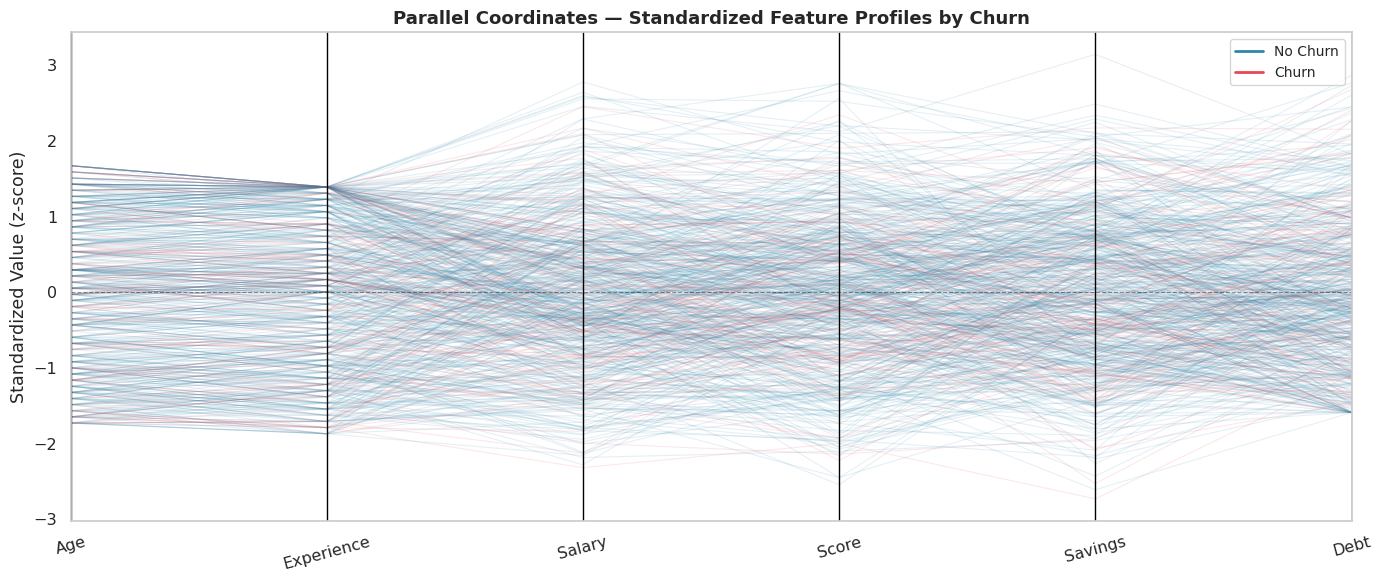

In [9]:
# Standardize for comparable axes
feat_cols = ['Age', 'Experience', 'Salary', 'Score', 'Savings', 'Debt']
df_pc     = df[feat_cols + ['Churn']].copy()
scaler    = StandardScaler()
df_pc[feat_cols] = scaler.fit_transform(df_pc[feat_cols])
df_pc['Churn_label'] = df_pc['Churn'].map({0: 'No Churn', 1: 'Churn'})

fig, ax = plt.subplots(figsize=(14, 6))
parallel_coordinates(
    df_pc[feat_cols + ['Churn_label']],
    class_column='Churn_label',
    color=[COLORS['primary'], COLORS['secondary']],
    alpha=0.12, linewidth=0.8, ax=ax
)
ax.set_title('Parallel Coordinates — Standardized Feature Profiles by Churn',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Standardized Value (z-score)')
ax.tick_params(axis='x', rotation=15)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.4, linestyle='--',
           label='Population mean (z=0)')
handles = [
    plt.Line2D([0],[0], color=COLORS['primary'],   linewidth=2, label='No Churn'),
    plt.Line2D([0],[0], color=COLORS['secondary'], linewidth=2, label='Churn'),
]
ax.legend(handles=handles, fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

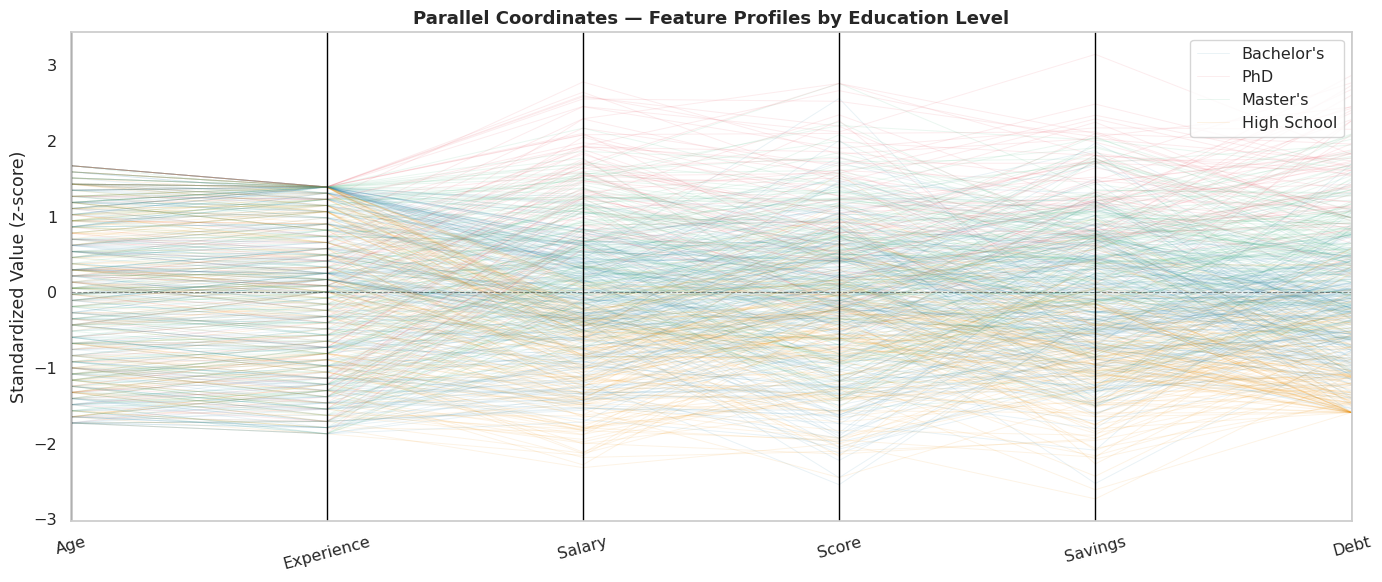

In [10]:
# ── Parallel coordinates — colored by Education ───────────────────────────
df_pc2 = df[feat_cols + ['Education']].copy()
df_pc2[feat_cols] = StandardScaler().fit_transform(df_pc2[feat_cols])

fig, ax = plt.subplots(figsize=(14, 6))
parallel_coordinates(
    df_pc2, class_column='Education',
    color=COLORS['palette'][:4],
    alpha=0.10, linewidth=0.7, ax=ax
)
ax.set_title('Parallel Coordinates — Feature Profiles by Education Level',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Standardized Value (z-score)')
ax.tick_params(axis='x', rotation=15)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

---
## 6️⃣ Radar / Spider Chart — Group Feature Profiles

> Each radial axis = one feature. Each polygon = the **mean feature profile** of a group.  
> Instantly communicates multi-dimensional group differences to any audience.
>
> ✅ Best for stakeholder reports and dashboard summaries.

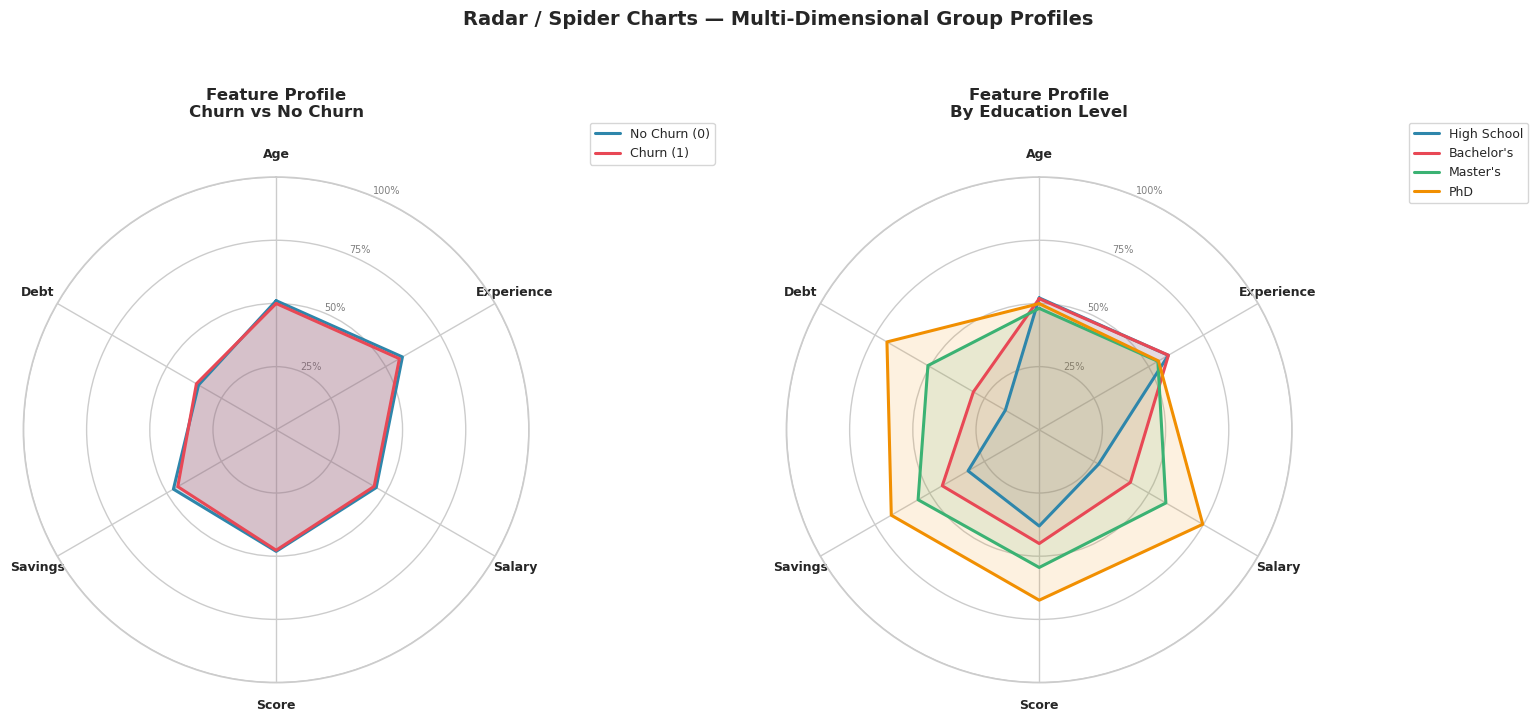

In [11]:
radar_cols = ['Age', 'Experience', 'Salary', 'Score', 'Savings', 'Debt']

# Min-max normalize to [0, 1] for comparability
df_radar = df[radar_cols + ['Churn', 'Education']].copy()
for col in radar_cols:
    mn, mx = df_radar[col].min(), df_radar[col].max()
    df_radar[col] = (df_radar[col] - mn) / (mx - mn)

def draw_radar(ax, values, labels, color, label, alpha=0.22):
    N      = len(labels)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    vals   = list(values) + [values[0]]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7, color='gray')
    ax.plot(angles, vals, color=color, linewidth=2.2, label=label)
    ax.fill(angles, vals, color=color, alpha=alpha)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw=dict(polar=True))

# Churn vs No Churn
for churn_val, color, label in [
    (0, COLORS['primary'],   'No Churn (0)'),
    (1, COLORS['secondary'], 'Churn (1)')
]:
    means = df_radar[df_radar['Churn'] == churn_val][radar_cols].mean().values
    draw_radar(axes[0], means, radar_cols, color, label)
axes[0].set_title('Feature Profile\nChurn vs No Churn',
                   fontsize=12, fontweight='bold', pad=22)
axes[0].legend(loc='upper right', bbox_to_anchor=(1.38, 1.12), fontsize=9)

# Education levels
for edu, color in zip(edu_order, COLORS['palette'][:4]):
    means = df_radar[df_radar['Education'] == edu][radar_cols].mean().values
    draw_radar(axes[1], means, radar_cols, color, edu, alpha=0.12)
axes[1].set_title('Feature Profile\nBy Education Level',
                   fontsize=12, fontweight='bold', pad=22)
axes[1].legend(loc='upper right', bbox_to_anchor=(1.48, 1.12), fontsize=9)

plt.suptitle('Radar / Spider Charts — Multi-Dimensional Group Profiles',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## 7️⃣ Correlation Matrix Heatmap

> Shows the **Pearson r** between every pair of numerical features.  
> Strong correlations (|r| > 0.75) signal potential multicollinearity.
>
> ✅ Run before every model — redundant features can hurt linear models.

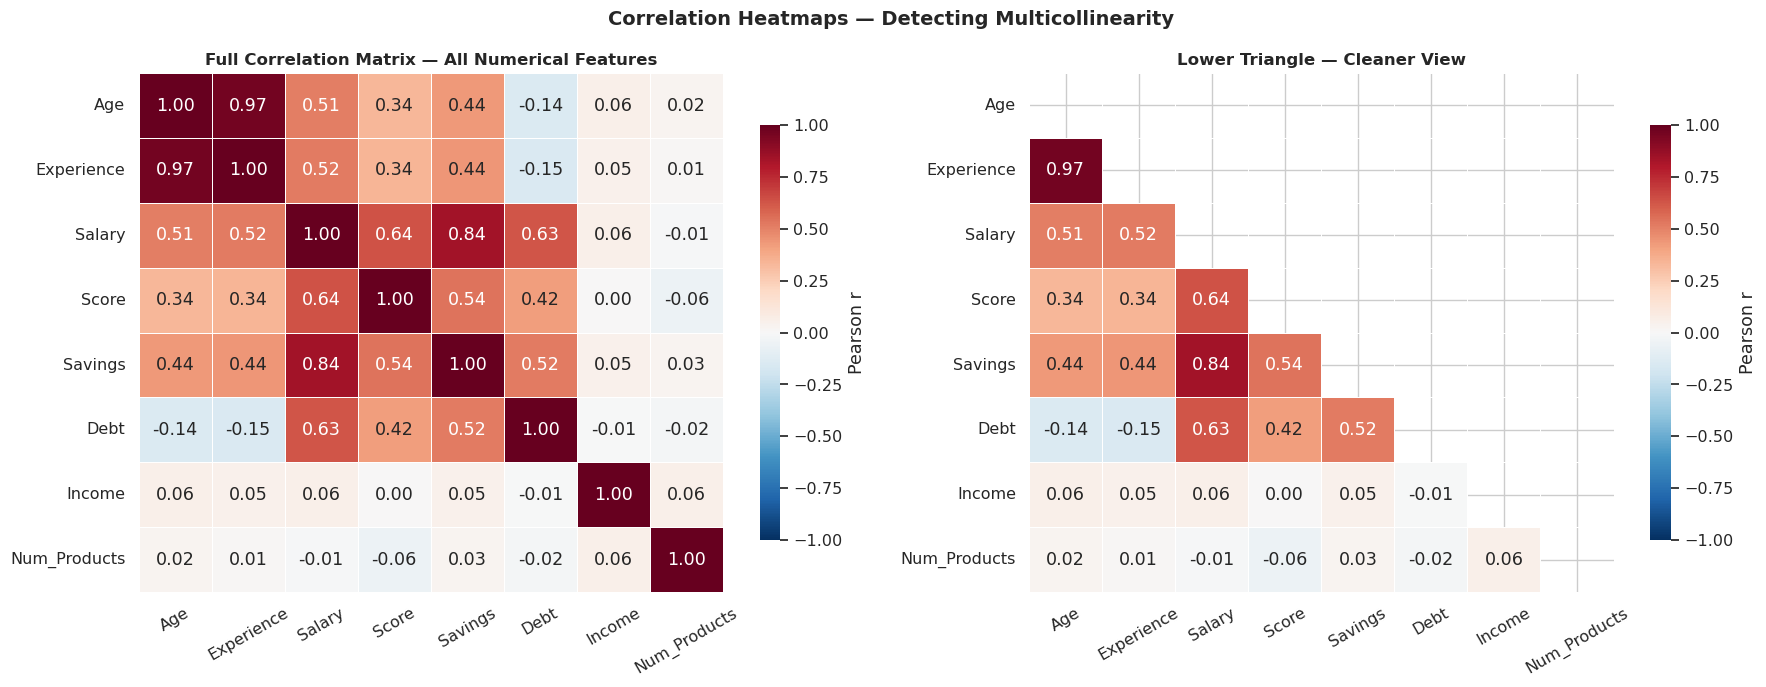


🔍 High Correlation Pairs (|r| > 0.50):
────────────────────────────────────────────────────
  Age             × Experience       r = +0.968  ⚠️  Very High
  Age             × Salary           r = +0.515    Moderate
  Experience      × Salary           r = +0.517    Moderate
  Salary          × Score            r = +0.638    Moderate
  Salary          × Savings          r = +0.840  ⚠️  Very High
  Salary          × Debt             r = +0.628    Moderate
  Score           × Savings          r = +0.543    Moderate
  Savings         × Debt             r = +0.523    Moderate


In [12]:
corr_matrix = df[num_cols].corr(method='pearson')
mask_upper  = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full heatmap
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=axes[0],
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
axes[0].set_title('Full Correlation Matrix — All Numerical Features',
                   fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# Lower triangle only
sns.heatmap(
    corr_matrix, mask=mask_upper,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=axes[1],
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
axes[1].set_title('Lower Triangle — Cleaner View',
                   fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Correlation Heatmaps — Detecting Multicollinearity',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── High correlation report ───────────────────────────────────────────────
print('\n🔍 High Correlation Pairs (|r| > 0.50):')
print('─' * 52)
seen = set()
for a in corr_matrix.columns:
    for b in corr_matrix.columns:
        if a == b: continue
        key = tuple(sorted([a, b]))
        if key in seen: continue
        r = corr_matrix.loc[a, b]
        if abs(r) > 0.50:
            flag = '⚠️  Very High' if abs(r) > 0.75 else '  Moderate'
            print(f'  {a:15s} × {b:15s}  r = {r:+.3f}  {flag}')
        seen.add(key)

---
## 8️⃣ VIF Analysis — Regression Multicollinearity

> VIF measures how much one feature's variance is explained by all other features.  
> **VIF = 1** → no collinearity. **VIF > 10** → severe — consider dropping.
>
> ✅ Always run VIF before linear regression, Ridge, or Lasso models.

VIF Multicollinearity Report:
     Feature     VIF          Severity                      Action
  Experience 17.1300 🔴 Severe   (> 10) Consider dropping / merging
         Age 16.0900 🔴 Severe   (> 10) Consider dropping / merging
      Salary  7.5200 🟡 Moderate (5–10)         Investigate further
        Debt  3.4500  🟢 Low      (< 5)                   OK — keep
     Savings  3.4100  🟢 Low      (< 5)                   OK — keep
       Score  1.7000  🟢 Low      (< 5)                   OK — keep
Num_Products  1.0200  🟢 Low      (< 5)                   OK — keep
      Income  1.0100  🟢 Low      (< 5)                   OK — keep


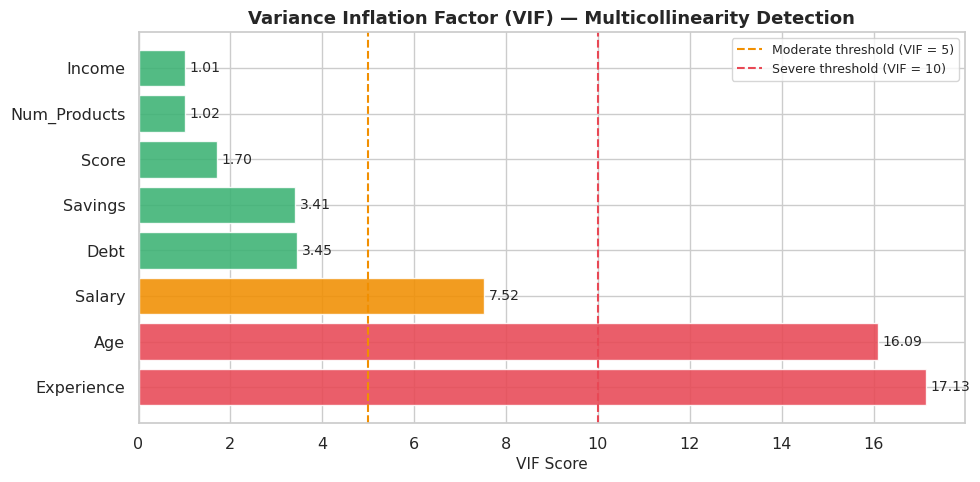

In [13]:
X_vif     = df[num_cols].dropna()
X_vif_sc  = pd.DataFrame(
    StandardScaler().fit_transform(X_vif), columns=num_cols
)

vif_df = pd.DataFrame({
    'Feature' : num_cols,
    'VIF'     : [variance_inflation_factor(X_vif_sc.values, i)
                 for i in range(len(num_cols))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_df['Severity'] = vif_df['VIF'].apply(
    lambda v: '🔴 Severe   (> 10)' if v > 10 else
              ('🟡 Moderate (5–10)' if v > 5  else
               '🟢 Low      (< 5)')
)
vif_df['Action'] = vif_df['VIF'].apply(
    lambda v: 'Consider dropping / merging' if v > 10 else
              ('Investigate further'        if v > 5  else
               'OK — keep')
)

print('VIF Multicollinearity Report:')
print(vif_df.round(2).to_string(index=False))

# ── VIF bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors  = [
    COLORS['secondary'] if v > 10 else
    COLORS['warning']   if v > 5  else
    COLORS['accent']
    for v in vif_df['VIF']
]
bars = ax.barh(vif_df['Feature'], vif_df['VIF'],
               color=colors, edgecolor='white', alpha=0.88)
ax.axvline(5,  color=COLORS['warning'],   linestyle='--', linewidth=1.5,
           label='Moderate threshold (VIF = 5)')
ax.axvline(10, color=COLORS['secondary'], linestyle='--', linewidth=1.5,
           label='Severe threshold (VIF = 10)')
for bar, val in zip(bars, vif_df['VIF']):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10)
ax.set_xlabel('VIF Score', fontsize=11)
ax.set_title('Variance Inflation Factor (VIF) — Multicollinearity Detection',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 9️⃣ PCA — 2D Projection

> PCA finds the **directions of maximum variance** (principal components) and  
> projects all data onto the first two for the best 2D view of high-dimensional structure.
>
> ✅ Always **StandardScale before PCA** — large-range features dominate otherwise.

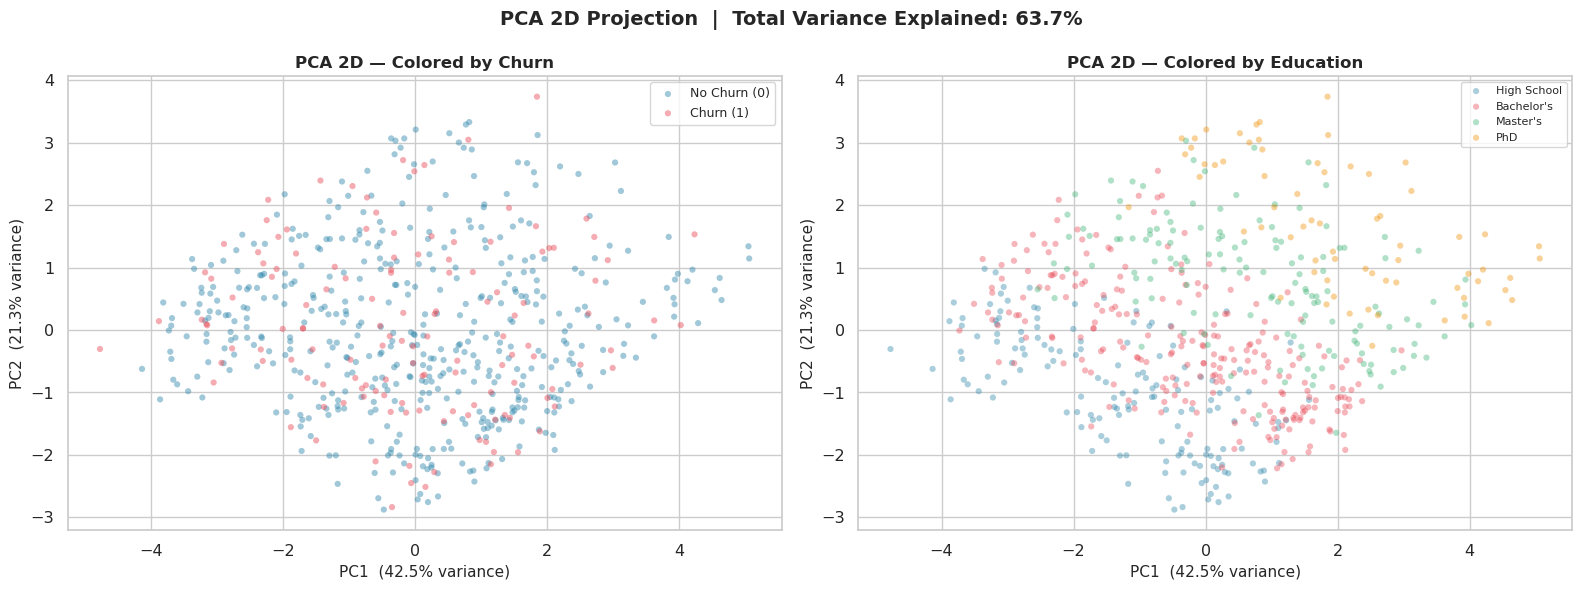

In [14]:
X_sc      = StandardScaler().fit_transform(df[num_cols])
pca_full  = PCA(random_state=42).fit(X_sc)                  # all components
pca_2d    = PCA(n_components=2, random_state=42)
X_pca_2d  = pca_2d.fit_transform(X_sc)
var_exp   = pca_2d.explained_variance_ratio_

pca_df = pd.DataFrame(X_pca_2d, columns=['PC1','PC2'])
pca_df['Churn']     = df['Churn'].values
pca_df['Education'] = df['Education'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colored by Churn
for churn_val, color, label in [
    (0, COLORS['primary'],   'No Churn (0)'),
    (1, COLORS['secondary'], 'Churn (1)')
]:
    mask = pca_df['Churn'] == churn_val
    axes[0].scatter(pca_df.loc[mask,'PC1'], pca_df.loc[mask,'PC2'],
                    c=color, alpha=0.45, s=20, label=label, edgecolors='none')
axes[0].set_xlabel(f'PC1  ({var_exp[0]*100:.1f}% variance)', fontsize=11)
axes[0].set_ylabel(f'PC2  ({var_exp[1]*100:.1f}% variance)', fontsize=11)
axes[0].set_title('PCA 2D — Colored by Churn', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Colored by Education
for edu, color in zip(edu_order, COLORS['palette'][:4]):
    mask = pca_df['Education'] == edu
    axes[1].scatter(pca_df.loc[mask,'PC1'], pca_df.loc[mask,'PC2'],
                    c=color, alpha=0.40, s=20, label=edu, edgecolors='none')
axes[1].set_xlabel(f'PC1  ({var_exp[0]*100:.1f}% variance)', fontsize=11)
axes[1].set_ylabel(f'PC2  ({var_exp[1]*100:.1f}% variance)', fontsize=11)
axes[1].set_title('PCA 2D — Colored by Education', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle(
    f'PCA 2D Projection  |  Total Variance Explained: {sum(var_exp)*100:.1f}%',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## 🔟 PCA — Scree Plot + Cumulative Variance

> The **scree plot** shows how much variance each component explains.  
> Choose the number of components at the **elbow** — where adding more yields diminishing returns.
>
> ✅ Target: enough components to explain **90–95%** of total variance.

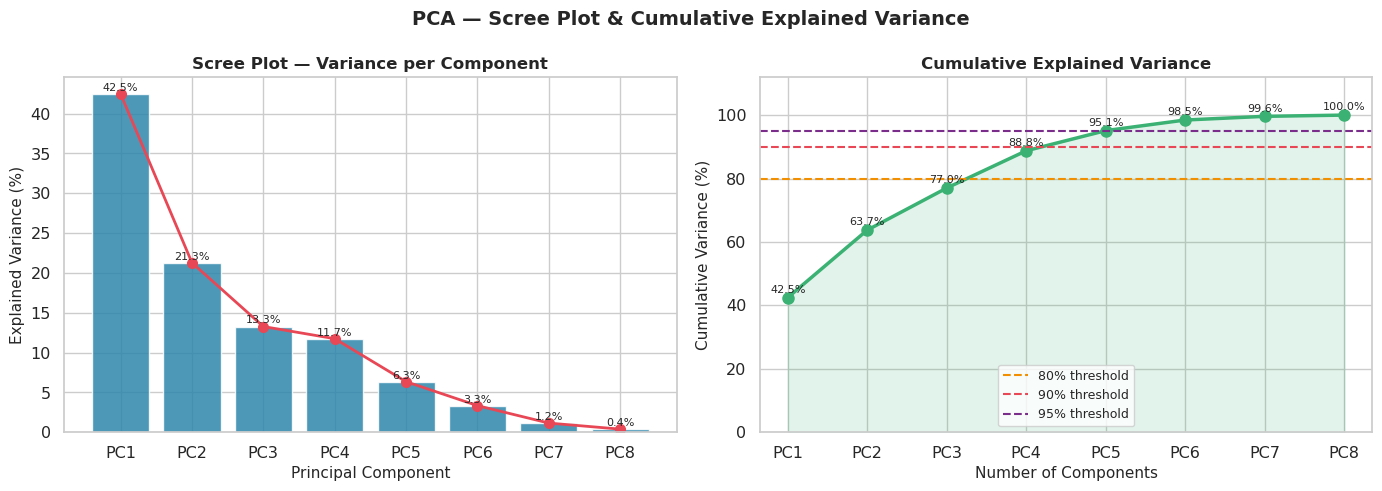

Component  Variance %  Cumulative %
      PC1     42.4700       42.4700
      PC2     21.2700       63.7500
      PC3     13.2700       77.0200
      PC4     11.7500       88.7600
      PC5      6.3500       95.1100
      PC6      3.3400       98.4600
      PC7      1.1500       99.6100
      PC8      0.3900      100.0000

→ Components needed for 90% variance: 5
→ Components needed for 95% variance: 5


In [15]:
evr     = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)
x_pos   = np.arange(1, len(evr) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(x_pos, evr * 100, color=COLORS['primary'], edgecolor='white', alpha=0.85)
axes[0].plot(x_pos, evr * 100, 'o-', color=COLORS['secondary'],
              linewidth=2, markersize=7)
for x, y in zip(x_pos, evr * 100):
    axes[0].text(x, y + 0.4, f'{y:.1f}%', ha='center', fontsize=8)
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance (%)', fontsize=11)
axes[0].set_title('Scree Plot — Variance per Component', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'PC{i}' for i in x_pos])

# Cumulative variance
axes[1].plot(x_pos, cum_evr * 100, 'o-', color=COLORS['accent'],
              linewidth=2.5, markersize=8)
axes[1].fill_between(x_pos, cum_evr * 100, color=COLORS['accent'], alpha=0.15)
for thresh, color, lbl in [
    (80, COLORS['warning'],   '80%'),
    (90, COLORS['secondary'], '90%'),
    (95, COLORS['purple'],    '95%'),
]:
    axes[1].axhline(thresh, color=color, linestyle='--',
                     linewidth=1.5, label=f'{lbl} threshold')
for x, y in zip(x_pos, cum_evr * 100):
    axes[1].text(x, y + 1.5, f'{y:.1f}%', ha='center', fontsize=8)
axes[1].set_xlabel('Number of Components', fontsize=11)
axes[1].set_ylabel('Cumulative Variance (%)', fontsize=11)
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'PC{i}' for i in x_pos])
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 112)

plt.suptitle('PCA — Scree Plot & Cumulative Explained Variance',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
scree_df = pd.DataFrame({
    'Component'      : [f'PC{i}' for i in x_pos],
    'Variance %'     : (evr * 100).round(2),
    'Cumulative %'   : (cum_evr * 100).round(2),
})
n90 = next(i+1 for i,c in enumerate(cum_evr) if c >= 0.90)
n95 = next(i+1 for i,c in enumerate(cum_evr) if c >= 0.95)
print(scree_df.to_string(index=False))
print(f'\n→ Components needed for 90% variance: {n90}')
print(f'→ Components needed for 95% variance: {n95}')

---
## 1️⃣1️⃣ PCA — Biplot (Feature Loading Directions)

> Overlays **feature loading vectors** on the 2D PCA scatter.  
> Each arrow shows how strongly and in which direction a feature drives PC1 and PC2.
>
> ✅ Long arrows = strong influence on components.  
> ✅ Arrows pointing same direction = positively correlated features.

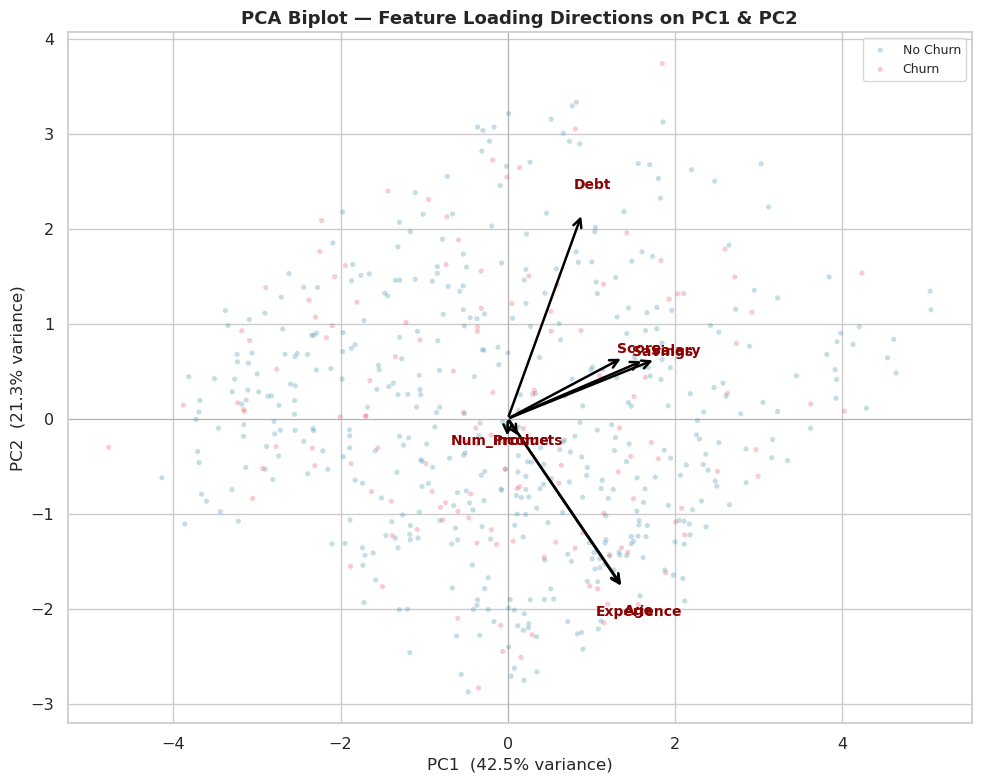

Feature Loadings (sorted by |PC1|):
              PC1 Loading  PC2 Loading  |PC1|  |PC2|
Salary             0.5042       0.1784 0.5042 0.1784
Savings            0.4653       0.1754 0.4653 0.1754
Score              0.3942       0.1842 0.3942 0.1842
Age                0.3924      -0.5064 0.3924 0.5064
Experience         0.3922      -0.5096 0.3922 0.5096
Debt               0.2538       0.6168 0.2538 0.6168
Income             0.0397      -0.0576 0.0397 0.0576
Num_Products      -0.0022      -0.0597 0.0022 0.0597


In [16]:
loadings = pca_2d.components_.T   # shape: (n_features, 2)
scale    = 3.5

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter — colored by Churn
for churn_val, color, label in [
    (0, COLORS['primary'],   'No Churn'),
    (1, COLORS['secondary'], 'Churn')
]:
    mask = df['Churn'].values == churn_val
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=color, alpha=0.28, s=14, label=label, edgecolors='none')

# Loading arrows + labels
for i, feature in enumerate(num_cols):
    ax.annotate('',
        xy=(loadings[i, 0] * scale, loadings[i, 1] * scale),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.8, mutation_scale=15)
    )
    ax.text(
        loadings[i, 0] * scale * 1.14,
        loadings[i, 1] * scale * 1.14,
        feature, fontsize=10, fontweight='bold',
        ha='center', va='center', color='darkred'
    )

ax.axhline(0, color='gray', linewidth=0.6, alpha=0.4)
ax.axvline(0, color='gray', linewidth=0.6, alpha=0.4)
ax.set_xlabel(f'PC1  ({var_exp[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2  ({var_exp[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Biplot — Feature Loading Directions on PC1 & PC2',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Loadings table
loadings_df = pd.DataFrame(
    loadings, index=num_cols, columns=['PC1 Loading','PC2 Loading']
).round(4)
loadings_df['|PC1|'] = loadings_df['PC1 Loading'].abs()
loadings_df['|PC2|'] = loadings_df['PC2 Loading'].abs()
print('Feature Loadings (sorted by |PC1|):')
print(loadings_df.sort_values('|PC1|', ascending=False).round(4).to_string())

---
## 1️⃣2️⃣ t-SNE — Non-Linear 2D Projection

> t-SNE preserves **local neighborhood structure** — nearby points in high-D  
> stay nearby in 2D. Reveals non-linear clusters that PCA cannot separate.
>
> ⚠️ Distances **between** clusters are NOT meaningful — only cluster membership is.  
> ⚠️ Always set `random_state` — t-SNE is stochastic.

  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


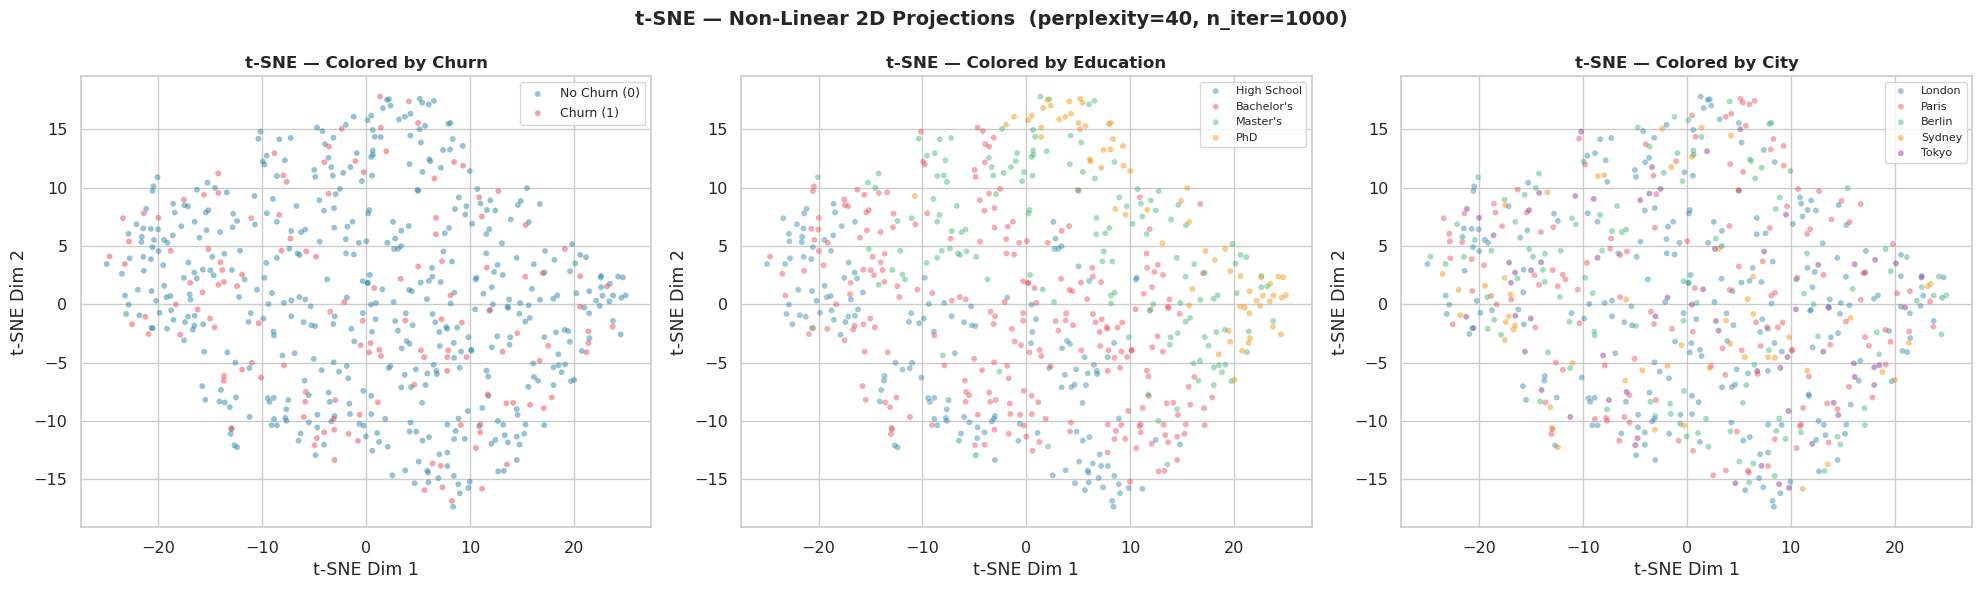

In [18]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,   # changed from n_iter
    random_state=42,
    learning_rate='auto',
    init='pca'
)

X_tsne = tsne.fit_transform(X_sc)
X_tsne = tsne.fit_transform(X_sc)

tsne_df = pd.DataFrame(X_tsne, columns=['tSNE_1','tSNE_2'])
tsne_df['Churn']     = df['Churn'].values
tsne_df['Education'] = df['Education'].values
tsne_df['City']      = df['City'].values

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# By Churn
for churn_val, color, label in [
    (0, COLORS['primary'],   'No Churn (0)'),
    (1, COLORS['secondary'], 'Churn (1)')
]:
    mask = tsne_df['Churn'] == churn_val
    axes[0].scatter(tsne_df.loc[mask,'tSNE_1'], tsne_df.loc[mask,'tSNE_2'],
                    c=color, alpha=0.50, s=18, label=label, edgecolors='none')
axes[0].set_title('t-SNE — Colored by Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('t-SNE Dim 1'); axes[0].set_ylabel('t-SNE Dim 2')
axes[0].legend(fontsize=9)

# By Education
for edu, color in zip(edu_order, COLORS['palette'][:4]):
    mask = tsne_df['Education'] == edu
    axes[1].scatter(tsne_df.loc[mask,'tSNE_1'], tsne_df.loc[mask,'tSNE_2'],
                    c=color, alpha=0.45, s=18, label=edu, edgecolors='none')
axes[1].set_title('t-SNE — Colored by Education', fontsize=12, fontweight='bold')
axes[1].set_xlabel('t-SNE Dim 1'); axes[1].set_ylabel('t-SNE Dim 2')
axes[1].legend(fontsize=8)

# By City
for city, color in zip(df['City'].unique(), COLORS['palette']):
    mask = tsne_df['City'] == city
    axes[2].scatter(tsne_df.loc[mask,'tSNE_1'], tsne_df.loc[mask,'tSNE_2'],
                    c=color, alpha=0.45, s=18, label=city, edgecolors='none')
axes[2].set_title('t-SNE — Colored by City', fontsize=12, fontweight='bold')
axes[2].set_xlabel('t-SNE Dim 1'); axes[2].set_ylabel('t-SNE Dim 2')
axes[2].legend(fontsize=8)

plt.suptitle('t-SNE — Non-Linear 2D Projections  (perplexity=40, n_iter=1000)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

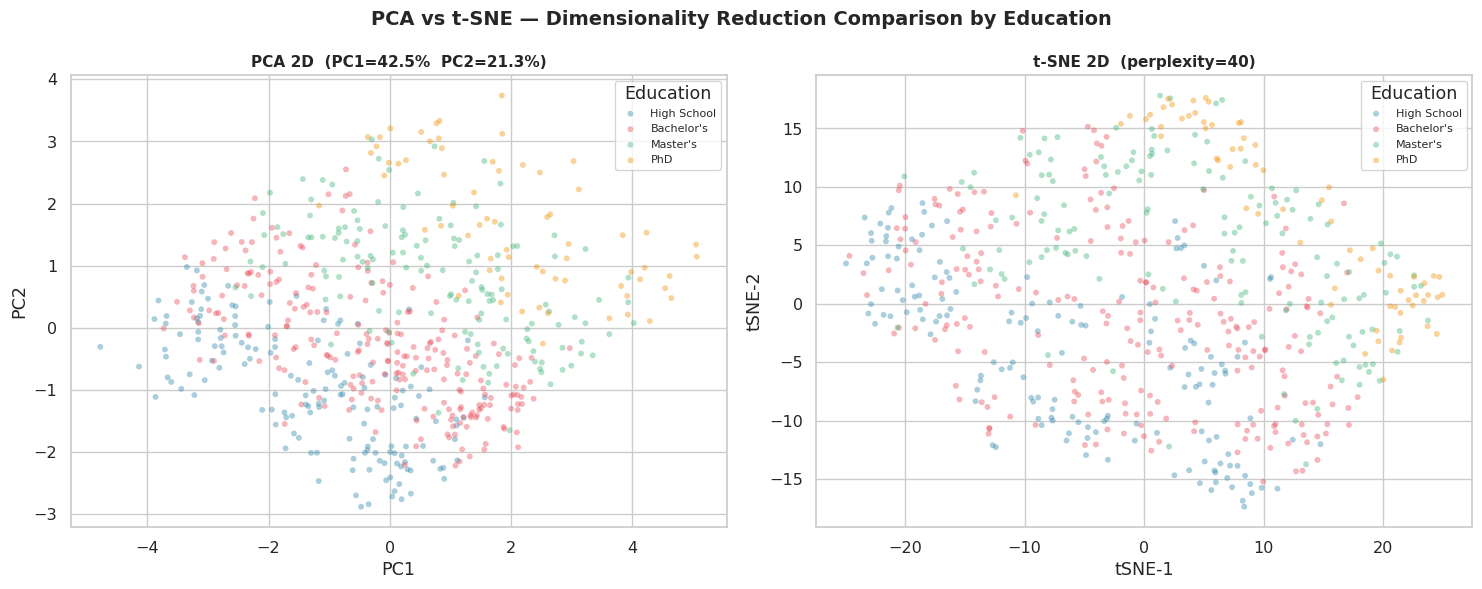

In [19]:
# ── PCA vs t-SNE side-by-side comparison ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_specs = [
    (axes[0], X_pca_2d[:,0], X_pca_2d[:,1],
     f'PCA 2D  (PC1={var_exp[0]*100:.1f}%  PC2={var_exp[1]*100:.1f}%)',
     'PC1', 'PC2'),
    (axes[1], X_tsne[:,0], X_tsne[:,1],
     't-SNE 2D  (perplexity=40)',
     'tSNE-1', 'tSNE-2'),
]
for ax, x_d, y_d, title, xl, yl in plot_specs:
    for edu, color in zip(edu_order, COLORS['palette'][:4]):
        mask = df['Education'].values == edu
        ax.scatter(x_d[mask], y_d[mask], c=color, alpha=0.40,
                   s=18, label=edu, edgecolors='none')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.legend(fontsize=8, title='Education')

plt.suptitle('PCA vs t-SNE — Dimensionality Reduction Comparison by Education',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📋 13. Automated Multivariate EDA Report

In [20]:
def multivariate_eda_report(df, num_cols, target):
    """
    Prints a 4-section multivariate EDA summary:
      1. Feature correlation with target
      2. VIF multicollinearity scores
      3. PCA explained variance
      4. High pairwise correlation pairs
    """
    sep = '=' * 65
    sub = '─' * 55
    print(sep)
    print('  📋  MULTIVARIATE EDA REPORT')
    print(sep)

    X    = df[num_cols].dropna()
    y    = df.loc[X.index, target]
    X_sc = StandardScaler().fit_transform(X)
    X_sc_df = pd.DataFrame(X_sc, columns=num_cols)

    # ── Section 1: Correlation with target ───────────────────────────────
    print('\n📌 SECTION 1 — Feature Correlation with Target')
    print(sub)
    rows = []
    for col in num_cols:
        r, p = pearsonr(X[col], y)
        rows.append({
            'Feature'    : col,
            'Pearson r'  : round(r, 4),
            '|r|'        : round(abs(r), 4),
            'p-value'    : round(p, 4),
            'Significant': '✅' if p < 0.05 else '❌',
            'Strength'   : ('Strong'   if abs(r) >= 0.5 else
                            'Moderate' if abs(r) >= 0.3 else
                            'Weak'     if abs(r) >= 0.1 else 'Negligible'),
        })
    corr_rpt = (pd.DataFrame(rows)
                  .sort_values('|r|', ascending=False)
                  .reset_index(drop=True))
    print(corr_rpt.to_string(index=False))

    # ── Section 2: VIF scores ─────────────────────────────────────────────
    print('\n📌 SECTION 2 — VIF Multicollinearity')
    print(sub)
    vif_rows = pd.DataFrame({
        'Feature' : num_cols,
        'VIF'     : [variance_inflation_factor(X_sc_df.values, i)
                     for i in range(len(num_cols))],
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    vif_rows['Status'] = vif_rows['VIF'].apply(
        lambda v: '🔴 Drop/Merge' if v > 10 else
                  ('🟡 Investigate' if v > 5 else '🟢 OK')
    )
    print(vif_rows.round(2).to_string(index=False))

    # ── Section 3: PCA variance summary ──────────────────────────────────
    print('\n📌 SECTION 3 — PCA Explained Variance')
    print(sub)
    pca_r  = PCA(random_state=42).fit(X_sc)
    evr_r  = pca_r.explained_variance_ratio_
    cum_r  = np.cumsum(evr_r)
    pca_tbl = pd.DataFrame({
        'Component'  : [f'PC{i+1}' for i in range(len(evr_r))],
        'Variance %' : (evr_r * 100).round(2),
        'Cumulative %': (cum_r * 100).round(2),
    })
    print(pca_tbl.to_string(index=False))
    n90 = next(i+1 for i,c in enumerate(cum_r) if c >= 0.90)
    n95 = next(i+1 for i,c in enumerate(cum_r) if c >= 0.95)
    print(f'\n  → Components for 90% variance: {n90}')
    print(f'  → Components for 95% variance: {n95}')

    # ── Section 4: High pairwise correlations ─────────────────────────────
    print('\n📌 SECTION 4 — High Pairwise Correlations (|r| > 0.60)')
    print(sub)
    corr_mat  = X.corr()
    seen      = set()
    found_any = False
    for a in corr_mat.columns:
        for b in corr_mat.columns:
            if a == b: continue
            key = tuple(sorted([a, b]))
            if key in seen: continue
            r_val = corr_mat.loc[a, b]
            if abs(r_val) > 0.60:
                flag = '⚠️  Very High' if abs(r_val) > 0.80 else '  High'
                print(f'  {a:15s} × {b:15s}  r = {r_val:+.3f}  {flag}')
                found_any = True
            seen.add(key)
    if not found_any:
        print('  No high correlation pairs (|r| ≤ 0.60) ✅')

    print('\n' + sep)
    print('  ✅ Multivariate EDA Report Complete')
    print(sep)


multivariate_eda_report(df, num_cols, target)

  📋  MULTIVARIATE EDA REPORT

📌 SECTION 1 — Feature Correlation with Target
───────────────────────────────────────────────────────
     Feature  Pearson r    |r|  p-value Significant   Strength
      Income    -0.0966 0.0966   0.0180           ✅ Negligible
     Savings    -0.0487 0.0487   0.2340           ❌ Negligible
      Salary    -0.0199 0.0199   0.6259           ❌ Negligible
  Experience    -0.0187 0.0187   0.6469           ❌ Negligible
        Debt     0.0181 0.0181   0.6585           ❌ Negligible
         Age    -0.0157 0.0157   0.7005           ❌ Negligible
Num_Products     0.0100 0.0100   0.8071           ❌ Negligible
       Score    -0.0099 0.0099   0.8089           ❌ Negligible

📌 SECTION 2 — VIF Multicollinearity
───────────────────────────────────────────────────────
     Feature     VIF        Status
  Experience 17.1300  🔴 Drop/Merge
         Age 16.0900  🔴 Drop/Merge
      Salary  7.5200 🟡 Investigate
        Debt  3.4500          🟢 OK
     Savings  3.4100          🟢 O

---
## ✅ 14. Summary & Best Practices

| Technique | Variables | Primary Purpose |
|-----------|:---------:|-----------------|
| **Pair Plot** | All numerical | All pairwise relationships in one grid |
| **Hue Scatter** | 2 Num + 1 Cat | Feature-class separation check |
| **Bubble Chart** | 3–4 mixed | Compact 4D visualization |
| **3D Scatter** | 3 numerical | True 3D cluster structure |
| **Parallel Coords** | All features | High-dimensional class profiles |
| **Radar Chart** | 5–8 features | Group profile — stakeholder reports |
| **Correlation Heatmap** | All numerical | Detect pairwise multicollinearity |
| **VIF Analysis** | All numerical | Regression multicollinearity score |
| **PCA 2D** | All numerical | Linear dim reduction + visualization |
| **PCA Scree** | All numerical | Choose number of components to keep |
| **PCA Biplot** | All numerical | Feature loading directions per PC |
| **t-SNE 2D** | All numerical | Non-linear cluster structure |

### 🔑 Golden Rules

1. **Always StandardScale before PCA and t-SNE** — scale-sensitive algorithms
2. **Pair plot first** — fastest way to see all relationships and class separation
3. **PCA distances ARE meaningful; t-SNE distances are NOT** — trust cluster shape only
4. **VIF > 10 → drop or merge** the offending features before linear models
5. **Scree plot elbow = number of PCA components** — target 90–95% cumulative variance
6. **Radar charts are best for stakeholder reports** — intuitive group comparison
7. **Parallel coordinates need standardized axes** — always scale before plotting
8. **Run t-SNE with n_iter ≥ 1000** — low iterations give poor convergence
9. **Use `init='pca'` in t-SNE** — faster convergence and more stable results
10. **Biplot arrows same direction = positively correlated** features in feature space

---

## 🔗 Next Steps

- ➡️ `Correlation_Analysis/` — Deep-dive Pearson, Spearman, Kendall, and VIF
- ➡️ `04_Unsupervised_Learning/PCA/` — Mathematical PCA with full implementation
- ➡️ `04_Unsupervised_Learning/tSNE/` — t-SNE hyperparameter tuning guide
- ➡️ `04_Unsupervised_Learning/UMAP/` — Faster, global-structure-preserving alternative
- ➡️ `06_Feature_Selection/` — Use correlation + VIF insights to drop redundant features